In [1]:
!pip install yfinance

In [2]:
# read files shared via google-drive-link
# https://stackoverflow.com/questions/62759748/downloading-data-from-a-shared-google-drive-link-in-google-colab

!pip uninstall gdown -y && pip install gdown
!gdown -V

Found existing installation: gdown 5.2.0
Uninstalling gdown-5.2.0:
  Successfully uninstalled gdown-5.2.0
  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
Using cached gdown-5.2.0-py3-none-any.whl (18 kB)
gdown 5.2.0 at C:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages


In [3]:
!pip install pandas-datareader

In [4]:
!pip install plotly

In [5]:
!pip install matplotlib

In [6]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px

import time
from datetime import date

# for graphs
import matplotlib.pyplot as plt

# 0) Dataset for Modeling: Final Preparations

## 0.1) Importing data from Drive & defining variable sets
* automated version need to have a daily updated file/database entries

In [7]:
# https://stackoverflow.com/questions/62759748/downloading-data-from-a-shared-google-drive-link-in-google-colab
# truncated data from Module 2: https://drive.google.com/file/d/1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB/view?usp=sharing
!gdown https://drive.google.com/file/d/1mb0ae2M5AouSDlqcUnIwaHq7avwGNrmB/view?usp=sharing --fuzzy -O /content/




Error:

	[WinError 3] The system cannot find the path specified: '/content'

To report issues, please visit https://github.com/wkentaro/gdown/issues.


In [9]:
!pip install pyarrow

In [10]:
import pandas as pd

df = pd.read_parquet("../stocks_df_combined_2025_06_13.parquet.brotli")
df.head()


,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Month,...,growth_brent_oil_7d,growth_brent_oil_30d,growth_brent_oil_90d,growth_brent_oil_365d,growth_btc_usd_1d,growth_btc_usd_3d,growth_btc_usd_7d,growth_btc_usd_30d,growth_btc_usd_90d,growth_btc_usd_365d
0,0.054277,0.062259,0.054277,0.059598,1.031789e+09,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.059598,0.062791,0.059598,0.061726,3.081600e+08,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.061726,0.063323,0.061726,0.062791,1.331712e+08,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.062791,0.063323,0.060662,0.061194,6.776640e+07,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.061194,0.061726,0.059598,0.060130,4.789440e+07,0.0,0.0,MSFT,1986,1986-03-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# truncated
# df = pd.read_parquet("/content/stocks_df_combined_trunc_2014_2023.parquet.brotli", )

# full dataset for 33 stocks
df_full = pd.read_parquet("../stocks_df_combined_2025_06_13.parquet.brotli", )


In [12]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230262 entries, 0 to 5700
Columns: 203 entries, Open to growth_btc_usd_365d
dtypes: datetime64[ns](3), float64(129), int32(64), int64(5), object(2)
memory usage: 302.2+ MB


In [13]:
df_full.keys()

Index(['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits',
       'Ticker', 'Year', 'Month',
       ...
       'growth_brent_oil_7d', 'growth_brent_oil_30d', 'growth_brent_oil_90d',
       'growth_brent_oil_365d', 'growth_btc_usd_1d', 'growth_btc_usd_3d',
       'growth_btc_usd_7d', 'growth_btc_usd_30d', 'growth_btc_usd_90d',
       'growth_btc_usd_365d'],
      dtype='object', length=203)

In [14]:
# growth indicators (but not future growth)
GROWTH = [g for g in df_full.keys() if (g.find('growth_')==0)&(g.find('future')<0)]
GROWTH

['growth_1d',
 'growth_3d',
 'growth_7d',
 'growth_30d',
 'growth_90d',
 'growth_365d',
 'growth_dax_1d',
 'growth_dax_3d',
 'growth_dax_7d',
 'growth_dax_30d',
 'growth_dax_90d',
 'growth_dax_365d',
 'growth_snp500_1d',
 'growth_snp500_3d',
 'growth_snp500_7d',
 'growth_snp500_30d',
 'growth_snp500_90d',
 'growth_snp500_365d',
 'growth_dji_1d',
 'growth_dji_3d',
 'growth_dji_7d',
 'growth_dji_30d',
 'growth_dji_90d',
 'growth_dji_365d',
 'growth_epi_1d',
 'growth_epi_3d',
 'growth_epi_7d',
 'growth_epi_30d',
 'growth_epi_90d',
 'growth_epi_365d',
 'growth_gold_1d',
 'growth_gold_3d',
 'growth_gold_7d',
 'growth_gold_30d',
 'growth_gold_90d',
 'growth_gold_365d',
 'growth_wti_oil_1d',
 'growth_wti_oil_3d',
 'growth_wti_oil_7d',
 'growth_wti_oil_30d',
 'growth_wti_oil_90d',
 'growth_wti_oil_365d',
 'growth_brent_oil_1d',
 'growth_brent_oil_3d',
 'growth_brent_oil_7d',
 'growth_brent_oil_30d',
 'growth_brent_oil_90d',
 'growth_brent_oil_365d',
 'growth_btc_usd_1d',
 'growth_btc_usd_3d',


In [15]:
# leaving only Volume ==> generate ln(Volume)
OHLCV = ['Open','High','Low','Close','Adj Close_x','Volume']

In [16]:
CATEGORICAL = ['Month', 'Weekday', 'Ticker', 'ticker_type']

In [17]:
TO_PREDICT = [g for g in df_full.keys() if (g.find('future')>=0)]
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [18]:
TO_DROP = ['Year','Date','index_x', 'index_y', 'index', 'Quarter','Adj Close_y'] + CATEGORICAL + OHLCV
TO_DROP

['Year',
 'Date',
 'index_x',
 'index_y',
 'index',
 'Quarter',
 'Adj Close_y',
 'Month',
 'Weekday',
 'Ticker',
 'ticker_type',
 'Open',
 'High',
 'Low',
 'Close',
 'Adj Close_x',
 'Volume']

In [19]:
# let's define on more custom numerical features
df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x))

C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\2841410488.py:2: RuntimeWarning: divide by zero encountered in log
  df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x))


In [20]:
import numpy as np

df_full['ln_volume'] = df_full['Volume'].apply(lambda x: np.log(x) if x > 0 else np.nan)


In [21]:
# manually defined features
CUSTOM_NUMERICAL = ['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume']

In [22]:
# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md

TECHNICAL_INDICATORS = ['adx', 'adxr', 'apo', 'aroon_1','aroon_2', 'aroonosc',
 'bop', 'cci', 'cmo','dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext',
 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix',
 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo',
 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk',
 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr',
 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase',
 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine',
 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice']

In [23]:
TECHNICAL_PATTERNS = [g for g in df_full.keys() if g.find('cdl')>=0]
print(f'Technical patterns count = {len(TECHNICAL_PATTERNS)}, examples = {TECHNICAL_PATTERNS[0:5]}')


Technical patterns count = 61, examples = ['cdl2crows', 'cdl3blackrows', 'cdl3inside', 'cdl3linestrike', 'cdl3outside']


In [24]:
MACRO = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS',
 'DGS1', 'DGS5', 'DGS10']

In [25]:
NUMERICAL = GROWTH + TECHNICAL_INDICATORS + TECHNICAL_PATTERNS + CUSTOM_NUMERICAL + MACRO

In [26]:
# CHECK: NO OTHER INDICATORS LEFT
OTHER = [k for k in df_full.keys() if k not in OHLCV + CATEGORICAL + NUMERICAL + TO_DROP]
OTHER

['Close_x',
 'Dividends',
 'Stock Splits',
 'growth_future_30d',
 'is_positive_growth_30d_future',
 'Close_y']

In [27]:
df_full.Ticker.nunique()

33

In [28]:
# tickers, min-max date, count of daily observations
df_full.groupby(['Ticker'])['Date'].agg(['min','max','count'])

,min,max,count
Ticker,,,
AAPL,1980-12-12,2025-06-13,11217
ACN,2001-07-19,2025-06-13,6012
AMZN,1997-05-15,2025-06-13,7065
ASML,1995-03-15,2025-06-13,7614
AVGO,2009-08-06,2025-06-13,3989
BHARTIARTL.NS,2002-07-01,2025-06-13,5698
BRK-B,1996-05-09,2025-06-13,7322
CDI.PA,1992-01-27,2025-06-13,8610
GOOG,2004-08-19,2025-06-13,5239


In [29]:
# truncated df_full with 25 years of data (and defined growth variables)
df = df_full[df_full.Date>='2000-01-01']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 204 entries, Open to ln_volume
dtypes: datetime64[ns](3), float64(130), int32(64), int64(5), object(2)
memory usage: 253.1+ MB


In [30]:
# let look at the features count and df size:
df[NUMERICAL].info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 184 entries, growth_1d to DGS10
dtypes: float64(121), int32(62), int64(1)
memory usage: 225.3 MB


## 0.2) [Code snippet 1] Generating dummies

In [31]:
# what are the categorical features?
CATEGORICAL

['Month', 'Weekday', 'Ticker', 'ticker_type']

In [32]:
# # dummy variables are not generated from Date and numeric variables
# df.loc[:,'Month'] = df.Month.dt.strftime('%B')
# df.loc[:,'Weekday'] = df.Weekday.astype(str)

In [33]:
# Ensure your Date column is datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month name and Weekday name from Date
df['Month'] = df['Date'].dt.strftime('%B')
df['Weekday'] = df['Date'].dt.strftime('%A')


C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\1611366498.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\1611366498.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.strftime('%B')
C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\1611366498.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [34]:
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')  # convert to datetime
df['Month'] = df['Month'].dt.strftime('%B')                 # convert to full month name


C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\993947067.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'], errors='coerce')  # convert to datetime
C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\993947067.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = pd.to_datetime(df['Month'], errors='coerce')  # convert to datetime
C:\Users\rahul\AppData\Local\Temp\ipykernel_6136\993947067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

In [35]:
df = pd.get_dummies(df, columns=['Month', 'Weekday'], drop_first=True)


In [36]:
# df = df.copy()  # prevent SettingWithCopyWarning entirely
# df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m-%d', errors='coerce')
# df['Month'] = df['Month'].dt.strftime('%B')


In [37]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.strftime('%B')  # Full month name, like 'January'
df['Weekday'] = df['Date'].dt.strftime('%A')  # Full weekday name, like 'Monday'


In [38]:
# Generate dummy variables (no need for bool, let's have int32 instead)
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')

In [39]:
# TODO 1: define more categorical features, e.g. all combinations for <September+weekday>  (you'll see that September is actually an important dummy in one of the models)

In [40]:
dummy_variables.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Month_April           191795 non-null  int32
 1   Month_August          191795 non-null  int32
 2   Month_December        191795 non-null  int32
 3   Month_February        191795 non-null  int32
 4   Month_January         191795 non-null  int32
 5   Month_July            191795 non-null  int32
 6   Month_June            191795 non-null  int32
 7   Month_March           191795 non-null  int32
 8   Month_May             191795 non-null  int32
 9   Month_November        191795 non-null  int32
 10  Month_October         191795 non-null  int32
 11  Month_September       191795 non-null  int32
 12  Weekday_Friday        191795 non-null  int32
 13  Weekday_Monday        191795 non-null  int32
 14  Weekday_Saturday      191795 non-null  int32
 15  Weekday_Sunday        191795 non-null 

In [41]:
# get dummies names in a list
DUMMIES = dummy_variables.keys().to_list()

In [42]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

In [43]:
df_with_dummies[NUMERICAL+DUMMIES].info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 245 entries, growth_1d to ticker_type_US
dtypes: bool(6), float64(121), int32(117), int64(1)
memory usage: 266.7 MB


## 0.3) [Code Snippet 2] Correlation analysis
* first approximation of "important" variables correlated with all variables we want to predict (TO_PREDICT)

In [44]:
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [45]:
corr_is_positive_growth_30d_future = df_with_dummies[NUMERICAL+DUMMIES+TO_PREDICT].corr()['is_positive_growth_30d_future']

In [46]:
# create a dataframe for an easy way to sort
corr_is_positive_growth_30d_future_df = pd.DataFrame(corr_is_positive_growth_30d_future)

In [47]:
corr_is_positive_growth_30d_future_df.sort_values(by='is_positive_growth_30d_future').head(5)

,is_positive_growth_30d_future
DGS10,-0.067204
DGS5,-0.059812
gdppot_us_yoy,-0.058374
gdppot_us_qoq,-0.058125
growth_brent_oil_365d,-0.056158


In [48]:
corr_is_positive_growth_30d_future_df.sort_values(by='is_positive_growth_30d_future').tail(8)

,is_positive_growth_30d_future
growth_btc_usd_7d,0.028577
Month_November,0.033807
Month_October,0.035410
growth_future_30d,0.696468
is_positive_growth_30d_future,1.000000
cdl3starsinsouth,NaN
cdlconcealbabyswall,NaN
cdlmathold,NaN


In [49]:
corr_growth_future_30d = df_with_dummies[NUMERICAL+DUMMIES+TO_PREDICT].corr()['growth_future_30d']

In [50]:
corr_growth_future_30d_df = pd.DataFrame(corr_growth_future_30d)

In [51]:
corr_growth_future_30d_df.sort_values(by='growth_future_30d').head(5)

,growth_future_30d
growth_brent_oil_365d,-0.084665
growth_dji_365d,-0.075940
growth_dax_365d,-0.060016
growth_wti_oil_365d,-0.055917
growth_snp500_365d,-0.055443


In [52]:
corr_growth_future_30d_df.sort_values(by='growth_future_30d').tail(8)

,growth_future_30d
ln_volume,0.052015
Ticker_NVDA,0.052434
Month_October,0.054752
is_positive_growth_30d_future,0.696468
growth_future_30d,1.000000
cdl3starsinsouth,NaN
cdlconcealbabyswall,NaN
cdlmathold,NaN


## 0.4) [Code snippet 3] Temporal split of ~25 years of data (by date)

In [53]:
def temporal_split(df, min_date, max_date, train_prop=0.7, val_prop=0.15, test_prop=0.15):
    """
    Splits a DataFrame into three buckets based on the temporal order of the 'Date' column.

    Args:
        df (DataFrame): The DataFrame to split.
        min_date (str or Timestamp): Minimum date in the DataFrame.
        max_date (str or Timestamp): Maximum date in the DataFrame.
        train_prop (float): Proportion of data for training set (default: 0.6).
        val_prop (float): Proportion of data for validation set (default: 0.2).
        test_prop (float): Proportion of data for test set (default: 0.2).

    Returns:
        DataFrame: The input DataFrame with a new column 'split' indicating the split for each row.
    """
    # Define the date intervals
    train_end = min_date + pd.Timedelta(days=(max_date - min_date).days * train_prop)
    val_end = train_end + pd.Timedelta(days=(max_date - min_date).days * val_prop)

    # Assign split labels based on date ranges
    split_labels = []
    for date in df['Date']:
        if date <= train_end:
            split_labels.append('train')
        elif date <= val_end:
            split_labels.append('validation')
        else:
            split_labels.append('test')

    # Add 'split' column to the DataFrame
    df['split'] = split_labels

    return df

In [54]:
min_date_df = df_with_dummies.Date.min()
max_date_df = df_with_dummies.Date.max()

df_with_dummies = temporal_split(df_with_dummies,
                                 min_date = min_date_df,
                                 max_date = max_date_df)

In [55]:
df_with_dummies['split'].value_counts()/len(df_with_dummies)

split
train         0.676399
test          0.163758
validation    0.159843
Name: count, dtype: float64

In [56]:
# remove the "segmentation" problem (warning message on df performance after many joins and data transformations)
new_df = df_with_dummies.copy()

# 1) Modeling: "rule of thumb" or hand-predictions

In [57]:
# let's have a time-series or one ticker
df_nvda = new_df[new_df.Ticker=='NVDA']

In [58]:
pip install --upgrade nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.


In [59]:
# fig = px.line(df_nvda, x="Date", y="Close_x", title='NVDA price')
# fig.show()

In [60]:
dupe_cols = df_nvda.columns[df_nvda.columns.duplicated()]
print(dupe_cols)


Index(['Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday',
       'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday'],
      dtype='object')


In [61]:
df_nvda = df_nvda.loc[:, ~df_nvda.columns.duplicated()]


In [62]:
import plotly.express as px

# Optional: ensure 'Date' is datetime
df_nvda['Date'] = pd.to_datetime(df_nvda['Date'], errors='coerce')

fig = px.line(df_nvda, x="Date", y="Close_x", title="NVDA Price")
fig.show()


In [63]:
# TRAIN / VALIDATION/ TEST split

# Calculate the lengths of each split -- this is not temporal split, but based on the number of observations --> "classic" split with no shuffle
total_length = len(df_nvda)
train_length = int(0.8 * total_length)
val_length = int(0.1 * total_length)

# Split the data
train_data = df_nvda.iloc[:train_length]
val_data = df_nvda.iloc[train_length:train_length+val_length]
test_data = df_nvda.iloc[train_length+val_length:]

# Plot the data
fig = px.line(title='NVDA Close price daily for three time intervals Train/Validation/Test')
fig.add_scatter(x=train_data['Date'], y=train_data['Close_x'], mode='lines', name='Train', line=dict(color='blue'))
fig.add_scatter(x=val_data['Date'], y=val_data['Close_x'], mode='lines', name='Validation', line=dict(color='orange'))
fig.add_scatter(x=test_data['Date'], y=test_data['Close_x'], mode='lines', name='Test', line=dict(color='green'))

# Update layout to center the title
fig.update_layout(title=dict(x=0.5))

fig.show()

In [64]:
# HIST ON NVDA DATA Train/Test/Validation
import plotly.graph_objects as go

# Plot the data
fig = go.Figure()

# Add histograms for each split
fig.add_trace(go.Histogram(x=train_data['growth_future_30d'], name='Train', opacity=0.75))
fig.add_trace(go.Histogram(x=val_data['growth_future_30d'], name='Validation', opacity=0.75))
fig.add_trace(go.Histogram(x=test_data['growth_future_30d'], name='Test', opacity=0.75))

fig.update_layout(barmode='overlay', title='Distribution of growth_future_30d for NVIDIA (NVDA) Growth by Train/Valid/Test sets')
fig.update_traces(opacity=0.75)

fig.show()


In [65]:
# HIST ON ALL DATA Train/Test/Validation
# comment: there are some outliers and hard co compare the distributions
import plotly.graph_objects as go

# Plot the data
fig = go.Figure()

# Add histograms for each split
fig.add_trace(go.Histogram(x=df_with_dummies[df_with_dummies.split=='train']['growth_future_30d'], name='Train', opacity=0.75))
fig.add_trace(go.Histogram(x=df_with_dummies[df_with_dummies.split=='validation']['growth_future_30d'], name='Validation', opacity=0.75))
fig.add_trace(go.Histogram(x=df_with_dummies[df_with_dummies.split=='test']['growth_future_30d'], name='Test', opacity=0.75))

fig.update_layout(barmode='overlay', title='Distribution of growth_future_30d for All tickers Growth by Train/Valid/Test sets')
fig.update_traces(opacity=0.75)

fig.show()

In [66]:
# # Assuming df_with_dummies is your DataFrame containing the 'growth_future_5d' variable and 'split' column

# # Create the histogram
# fig = px.histogram(new_df,
#                    x="growth_future_30d",
#                    color="split",
#                    marginal="box", # or violin, rug
#                    )
#                   #  hover_data=new_df.growth_future_5d)

# # Show the histogram
# fig.show()

In [67]:
new_df = new_df.loc[:, ~new_df.columns.duplicated()]


In [68]:
import plotly.express as px

fig = px.histogram(
    new_df,
    x="growth_future_30d",
    color="split",
    marginal="box",  # or violin, rug
)
fig.show()


In [69]:
new_df.groupby(by='split')['growth_future_30d'].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,30418.0,1.019899,0.102172,0.580332,0.955986,1.016057,1.077950,1.648934
train,129730.0,1.023864,0.123190,0.246131,0.960248,1.020585,1.083310,5.179689
validation,30657.0,1.029596,0.099908,0.461847,0.973991,1.030784,1.086687,1.783610


In [70]:
# is_positive_growth_5d_future: ONLY NVDA stock

# Count occurrences of 0 and 1 for each split
train_counts = train_data['is_positive_growth_30d_future'].value_counts(normalize=True)*100
val_counts = val_data['is_positive_growth_30d_future'].value_counts(normalize=True)*100
test_counts = test_data['is_positive_growth_30d_future'].value_counts(normalize=True)*100

# Plot the data
fig = go.Figure()

# # Add stacked bar charts for each split
# fig.add_trace(go.Bar(x=['Train', 'Validation', 'Test'], y=[train_counts[0], val_counts[0], test_counts[0]], name='0'))
# fig.add_trace(go.Bar(x=['Train', 'Validation', 'Test'], y=[train_counts[1], val_counts[1], test_counts[1]], name='1'))


# Add stacked bar charts for each split
fig.add_trace(go.Bar(x=['Train', 'Validation', 'Test'], y=[train_counts[0], val_counts[0], test_counts[0]], name='0',
                     text=[f'{count:.2f}%' for count in [train_counts[0], val_counts[0], test_counts[0]]], textposition='auto'))
fig.add_trace(go.Bar(x=['Train', 'Validation', 'Test'], y=[train_counts[1], val_counts[1], test_counts[1]], name='1',
                     text=[f'{count:.2f}%' for count in [train_counts[1], val_counts[1], test_counts[1]]], textposition='auto'))


fig.update_layout(barmode='stack', title='Distribution of is_positive_growth_30d_future by Train/Validation/Test for NVDA stock')
fig.update_traces(opacity=0.75)

fig.show()

In [71]:
# ALL STOCKS: train/test/validation is more similar

# Count occurrences of 0 and 1 for each split
train_counts = df_with_dummies[df_with_dummies.split=='train']['is_positive_growth_30d_future'].value_counts(normalize=True)*100
val_counts = df_with_dummies[df_with_dummies.split=='validation']['is_positive_growth_30d_future'].value_counts(normalize=True)*100
test_counts = df_with_dummies[df_with_dummies.split=='test']['is_positive_growth_30d_future'].value_counts(normalize=True)*100

# Plot the data
fig = go.Figure()


# Add stacked bar charts for each split
fig.add_trace(go.Bar(x=['Train', 'Validation', 'Test'], y=[train_counts[0], val_counts[0], test_counts[0]], name='0',
                     text=[f'{count:.2f}%' for count in [train_counts[0], val_counts[0], test_counts[0]]], textposition='auto'))
fig.add_trace(go.Bar(x=['Train', 'Validation', 'Test'], y=[train_counts[1], val_counts[1], test_counts[1]], name='1',
                     text=[f'{count:.2f}%' for count in [train_counts[1], val_counts[1], test_counts[1]]], textposition='auto'))


fig.update_layout(barmode='stack', title='Distribution of is_positive_growth_30d_future by Train/Validation/Test for ALL stocks')
fig.update_traces(opacity=0.75)

fig.show()

# 1) Modeling: "rule of thumb" or hand-predictions

## 1.1) Review all the inputs again

In [72]:
# remove the "segmentation" problem (warning message on df performance after many joins and data transformations)
new_df = df_with_dummies.copy()

In [73]:
# Full dataframe (transformed and truncated to 25 years)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191795 entries, 3490 to 5700
Columns: 266 entries, Open to split
dtypes: bool(6), datetime64[ns](2), float64(130), int32(118), int64(5), object(5)
memory usage: 296.7+ MB


In [74]:
# check one record: it has abs. values, text, and numbers
new_df.head(1)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Date,...,Ticker_SAP,Ticker_SBIN.NS,Ticker_SIE.DE,Ticker_TCS.NS,Ticker_TTE,Ticker_V,ticker_type_EU,ticker_type_INDIA,ticker_type_US,split
3490,35.975752,36.358881,34.3283,35.726719,53228400.0,0.0,0.0,MSFT,2000,2000-01-03,...,0,0,0,0,0,0,0,0,1,train


In [75]:
# time split on train/validation/test: FIXED dates of split, approx. 70%, 15%, 15% split
new_df.groupby(['split'])['Date'].agg({'min','max','count'})

,min,count,max
split,,,
test,2021-08-20,31408,2025-06-13
train,2000-01-03,129730,2017-10-25
validation,2017-10-26,30657,2021-08-19


In [76]:
# what we try to predict
new_df[TO_PREDICT].head(1)

,growth_future_30d,is_positive_growth_30d_future
3490,0.845576,0


In [77]:
# to be used as features
new_df[NUMERICAL+DUMMIES].head(1)

,growth_1d,growth_3d,growth_7d,growth_30d,growth_90d,growth_365d,growth_dax_1d,growth_dax_3d,growth_dax_7d,growth_dax_30d,...,Ticker_RMS.PA,Ticker_SAP,Ticker_SBIN.NS,Ticker_SIE.DE,Ticker_TCS.NS,Ticker_TTE,Ticker_V,ticker_type_EU,ticker_type_INDIA,ticker_type_US
3490,0.998394,0.988341,0.991494,1.372333,1.22295,2.063054,0.970196,0.983855,1.051736,1.134572,...,0,0,0,0,0,0,0,0,0,1


## 1.2) [Code Snippet 3] Manual "hand rule" predictions
* CCI (binary, on technical indicator CCI)
* growth_1d>1
* growth_1d>1 & growth_snp500_1d>1
*

In [78]:
# why does it work?
# compare a vector (pandas.core.series.Series) with scalar 200 ==> element_wise comparison with the number ==> generate a new DataFrame
# (only 5 values)
pd.DataFrame(new_df.cci>200).head()

,cci
3490,False
3491,False
3492,False
3493,False
3494,False


In [79]:
# generate manual predictions
# Let's label all prediction features with prefix "pred"
new_df['pred0_manual_cci'] = (new_df.cci>200).astype(int)
new_df['pred1_manual_prev_g1'] = (new_df.growth_30d>1).astype(int)
new_df['pred2_manual_prev_g1_and_snp'] = ((new_df['growth_30d'] > 1) & (new_df['growth_snp500_30d'] > 1)).astype(int)

In [80]:
# TODO 2: find more "hand rules" - can get it from decision trees important factors, or randomly build on other most popular macro/tech indicators/ manual_features

In [81]:
new_df[['cci','growth_30d','growth_snp500_30d','pred0_manual_cci','pred1_manual_prev_g1','pred2_manual_prev_g1_and_snp','is_positive_growth_30d_future']].sample(10)

,cci,growth_30d,growth_snp500_30d,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,is_positive_growth_30d_future
4232,56.576677,0.939685,1.042231,0,0,0,0
5774,94.269252,1.053638,1.056786,0,1,1,0
6636,-51.495426,0.907735,0.866928,0,0,0,1
1282,42.752721,1.076990,0.994044,0,1,0,1
3401,144.054517,0.929498,0.950970,0,0,0,1
5491,-98.113872,0.876203,0.971759,0,0,0,1
5713,-23.489990,1.073732,1.016494,0,1,1,1
3365,73.270322,0.991150,1.064105,0,0,0,0
5106,65.940569,1.015473,1.001825,0,1,1,0
6085,-159.630987,0.832479,0.931687,0,0,0,0


In [82]:
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp']

In [83]:
p = PREDICTIONS[0]
part1 = p.split('_')[0] # first prefix before '_'
print(f'Full column name: {p}, only first part: {part1}')

Full column name: pred0_manual_cci, only first part: pred0


In [84]:
# One prediction: do we predict correctly?
new_df['is_correct_prediction'] = (new_df.pred0_manual_cci == new_df.is_positive_growth_30d_future)

In [85]:
new_df[['cci','pred0_manual_cci','is_positive_growth_30d_future','is_correct_prediction']]

,cci,pred0_manual_cci,is_positive_growth_30d_future,is_correct_prediction
3490,26.847443,0,0,True
3491,-34.318580,0,0,True
3492,-97.316604,0,0,True
3493,-169.947228,0,0,True
3494,-142.144015,0,0,True
...,...,...,...,...
5696,144.754024,0,0,True
5697,129.103741,0,0,True
5698,111.169291,0,0,True
5699,-22.369699,0,0,True


In [86]:
# check "Precision" : the percentage of "correct" predictions , WHEN we predict "1" (POSITIVE future growth)
filter = (new_df.split=='test') & (new_df.pred0_manual_cci==1)
new_df[filter].is_correct_prediction.value_counts()


is_correct_prediction
True     443
False    351
Name: count, dtype: int64

In [87]:
# %% of correct predictions : 54%
new_df[filter].is_correct_prediction.value_counts() / len(new_df[filter])

is_correct_prediction
True     0.557935
False    0.442065
Name: count, dtype: float64

In [88]:
# delete this column
del new_df["is_correct_prediction"]

In [89]:
# generate columns is_correct_
for pred in PREDICTIONS:
  part1 = pred.split('_')[0] # first prefix before '_'
  new_df[f'is_correct_{part1}'] =  (new_df[pred] == new_df.is_positive_growth_30d_future).astype(int)

In [90]:
# IS_CORRECT dataset
IS_CORRECT =  [k for k in new_df.keys() if k.startswith('is_correct_')]
IS_CORRECT

['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2']

In [91]:
# sample of a dataframe
new_df[PREDICTIONS+IS_CORRECT+['is_positive_growth_30d_future']].sample(5)

,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_positive_growth_30d_future
5393,0,0,0,1,1,1,0
5643,1,1,0,1,1,0,1
2771,0,1,1,0,1,1,1
2198,0,0,0,1,1,1,0
2413,0,1,1,0,1,1,1


In [92]:
len(new_df[new_df.split=='test'])

31408

In [93]:
# define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
for i,column in enumerate(IS_CORRECT):
  prediction_column = PREDICTIONS[i]
  is_correct_column = column
  filter = (new_df.split=='test') & (new_df[prediction_column]==1)
  print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
  print(new_df[filter][is_correct_column].value_counts())
  print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))

  print('---------')

Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    443
0    351
Name: count, dtype: int64
is_correct_pred0
1    0.557935
0    0.442065
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    9748
0    8243
Name: count, dtype: int64
is_correct_pred1
1    0.541826
0    0.458174
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    6984
0    6383
Name: count, dtype: int64
is_correct_pred2
1    0.522481
0    0.477519
Name: count, dtype: float64
---------


## 1.3) [Code Snippet 4 - Advanced] Statistical prediction : ARIMA models with 3 parameters (p,q,r)
* Finding best ARIMA params: not used in 2025

In [94]:

import pandas as pd

# Set 'Date' as the index
df_arima = df_nvda.copy()

df_arima.set_index('Date', inplace=True)
df_arima.head()

# use ONLY time-series values and no other features
train_validation = df_arima[df_arima.split.isin(['train','validation'])]['Close_x']
test = df_arima[df_arima.split.isin(['test'])]['Close_x']

# this is needed to make a decision about investing for 5 days
test_is_positive_future_30d = df_arima[df_arima.split.isin(['test'])]['is_positive_growth_30d_future']


In [95]:
# Upgrade numpy and cython
!pip install --upgrade numpy cython

# Uninstall pmdarima
!pip uninstall -y pmdarima

# Reinstall pmdarima from source (clean build)
!pip install --no-binary :all: --no-cache-dir pmdarima


  Using cached numpy-2.3.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.1-cp311-cp311-win_amd64.whl (13.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.10.0 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.3.1 which is incompatible.


Found existing installation: pmdarima 1.8.5
Uninstalling pmdarima-1.8.5:
  Successfully uninstalled pmdarima-1.8.5
     ---------------------------------------- 0.0/630.3 kB ? eta -:--:--
     ------------------------------------- 630.3/630.3 kB 11.9 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'


  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [403 lines of output]
      Ignoring numpy: markers 'python_version < "3.10"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.10" and platform_system != "Windows"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.10" and platform_system == "Windows"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.12"' don't match your environment
      Ignoring scipy: markers 'python_version <= "3.8" and platform_machine != "aarch64"' don't match your environment
      Ignoring scipy: markers 'python_version <= "3.8" and platform_machine == "aarch64"' don't match your environment
      Ignoring scipy: markers 'python_version == "3.9"' don't match your environment
      Ignoring scipy: markers 'python_version == "3.10"' don't match your environment
      Ignoring scipy:

In [96]:
!pip install scipy==1.10.1


  Using cached scipy-1.10.1-cp311-cp311-win_amd64.whl.metadata (58 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached scipy-1.10.1-cp311-cp311-win_amd64.whl (42.2 MB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.3.1

   ---------------------------------------- 0/2 [numpy]
    Uninstalling numpy-2.3.1:
   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-2.3.1
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   --------------------

In [97]:
!pip install pmdarima --only-binary :all:


  Using cached pmdarima-2.0.4-cp311-cp311-win_amd64.whl.metadata (8.0 kB)
Using cached pmdarima-2.0.4-cp311-cp311-win_amd64.whl (614 kB)


In [98]:
!pip install numpy==1.24.3


  Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl (14.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


In [191]:
!pip uninstall -y pmdarima
!pip install pmdarima


Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4
  Using cached pmdarima-2.0.4-cp311-cp311-win_amd64.whl (614 kB)



[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
!pip uninstall numpy -y
!pip install numpy==1.24.3
!pip uninstall pmdarima -y
!pip install --no-cache-dir --force-reinstall pmdarima



Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
  Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl (14.8 MB)
Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4
   ---------------------------------------- 0.0/614.7 kB ? eta -:--:--
   --------------------------------------- 614.7/614.7 kB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------- -------- 2.1/2.7 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 11.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
   ------- -------------------------------- 2.4/13.0 MB 11.2 MB/s eta 0:00:01
   -------------- ------------------------- 4.7/13.0 MB 11.0 MB/s eta 0:00:01
   -------------------- ------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [100]:
!pip install wheel


In [101]:
!pip install pmdarima==1.8.5 --no-build-isolation


  Using cached pmdarima-1.8.5-cp311-cp311-win_amd64.whl
  Attempting uninstall: pmdarima
    Found existing installation: pmdarima 2.0.4
    Uninstalling pmdarima-2.0.4:
      Successfully uninstalled pmdarima-2.0.4


# pre test

In [102]:
pip install numpy==1.24.3 --no-binary=:none: --force-reinstall

  Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-win_amd64.whl (14.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.16.0 requires numpy<2.6,>=1.25.2, but you have numpy 1.24.3 which is incompatible.


In [103]:
!pip install scipy==1.10.0 

  Using cached scipy-1.10.0-cp311-cp311-win_amd64.whl.metadata (58 kB)
Using cached scipy-1.10.0-cp311-cp311-win_amd64.whl (42.2 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.0
    Uninstalling scipy-1.16.0:
      Successfully uninstalled scipy-1.16.0


In [104]:
!pip install numpy>=1.25.2

In [105]:
from pmdarima.arima import auto_arima

best_arima_model = auto_arima(train_validation,
                   seasonal=False,
                   trace=True,          # Shows fitting progress
                   start_p=0, start_q=0, # Minimum p and q orders
                   max_p=12, max_q=12,  # Maximum p and q orders  
                   D=None,              # Let model determine differencing
                   error_action='ignore',  # Continue on warnings
                   suppress_warnings=True,
                   stepwise=True)       # Faster search method

print(best_arima_model.summary())

c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\pmdarima\compat\sklearn.py:7: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\rahul\sto

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-4622.853, Time=0.31 sec


c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-6715.745, Time=0.35 sec


c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

 ARIMA(9,2,4)(0,0,0)[0] intercept   : AIC=-8943.539, Time=16.88 sec


c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(11,2,4)(0,0,0)[0] intercept   : AIC=-8943.358, Time=19.48 sec


c:\Users\rahul\stock-markets-analytics-zoomcamp\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(10,2,3)(0,0,0)[0]             : AIC=inf, Time=9.28 sec

Best model:  ARIMA(10,2,3)(0,0,0)[0] intercept
Total fit time: 239.714 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5443
Model:              SARIMAX(10, 2, 3)   Log Likelihood                4497.597
Date:                Mon, 07 Jul 2025   AIC                          -8965.195
Time:                        21:15:39   BIC                          -8866.169
Sample:                             0   HQIC                         -8930.636
                               - 5443                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   7.955e-06   3.21e-05      0.248      0.804    -5.5e-05  

In [106]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # Temporarily suppress
warnings.filterwarnings("ignore", category=UserWarning)

In [107]:
#Hyper parameters optimization
# ~ several minutes to run
# https://miqbalrp.medium.com/exploring-autoarima-in-python-for-multiple-time-series-forecasting-2f3004ba5a49
# https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html
# Auto ARIMA model fitting: iterating across params
best_arima_model = auto_arima(train_validation,
                   seasonal=False,
                   trace=True,
                   start_p=0, start_q=0, # minimum p and q
                   max_p=12, max_q=12,   # maximum p and q
                   D=None,               # let model determine 'D'
                   )

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-4622.853, Time=0.39 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-6715.745, Time=0.43 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-4624.849, Time=0.18 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=-7363.101, Time=0.50 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=-7673.346, Time=0.58 sec
 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=-7896.947, Time=0.85 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=-8034.100, Time=1.09 sec
 ARIMA(6,2,0)(0,0,0)[0] intercept   : AIC=-8319.128, Time=1.18 sec
 ARIMA(7,2,0)(0,0,0)[0] intercept   : AIC=-8370.902, Time=2.19 sec
 ARIMA(8,2,0)(0,0,0)[0] intercept   : AIC=-8467.515, Time=1.82 sec
 ARIMA(9,2,0)(0,0,0)[0] intercept   : AIC=-8503.900, Time=2.31 sec
 ARIMA(10,2,0)(0,0,0)[0] intercept   : AIC=-8526.377, Time=2.46 sec
 ARIMA(11,2,0)(0,0,0)[0] intercept   : AIC=-8590.693, Time=2.04 sec
 ARIMA(12,2,0)(0,0,0)[0

In [ ]:
# #best model specification trained on train_validation
# # (p=6, q=2, r=2)
# best_arima_model.get_params()['order']

# model parameters ("coef" for auto-regression (AR) and moving-average (MA))
# best_arima_model.summary()

In [108]:
# 1. Get model order parameters (p,d,q)
print("Model order (p,d,q):", best_arima_model.get_params()['order'])

# 2. Print model summary (contains AR/MA coefficients)
print(best_arima_model.summary())

# 3. Access specific coefficients (alternative method)
print("\nAR coefficients:", best_arima_model.arparams())
print("MA coefficients:", best_arima_model.maparams())

Model order (p,d,q): (10, 2, 3)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5443
Model:              SARIMAX(10, 2, 3)   Log Likelihood                4497.597
Date:                Mon, 07 Jul 2025   AIC                          -8965.195
Time:                        21:22:32   BIC                          -8866.169
Sample:                             0   HQIC                         -8930.636
                               - 5443                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   7.955e-06   3.21e-05      0.248      0.804    -5.5e-05    7.09e-05
ar.L1         -0.4617      0.589     -0.783      0.433      -1.617       0.694
ar.L2         -0.162

In [109]:
# need to do 918 predictions for 1 stock
len(test)

958

In [110]:
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

In [111]:
# [last day] this was used to train the model and obtain the "best" params
train_validation[-1:]

Date
2021-08-19    19.756039
Name: Close_x, dtype: float64

In [112]:
# # history as Series and the "last value" (current last known data)
history = [x for x in train_validation]
history[-1]

19.756038665771484

In [113]:
# [last day] now need to predict for each value of test, using all available history
test[-1:]

Date
2025-06-13    141.970001
Name: Close_x, dtype: float64

In [114]:
# slow to predict, can't quickly predict for ALL 33 tickers * 918 observationa (~30k predictions). Let's have only 1 ticker and these periods to predict:
# change this to 10 (1 min) or 50 (5min) to run faster

PERIODS_TO_PREDICT = 10  # ~2 minute to predict
# PERIODS_TO_PREDICT = 500  #VERY SLOW: used for slides

In [115]:
# staring to predict at day1 of test dataframe (we SEE the adj_close price and predict 5 periods ahead)
df_arima[df_arima.split=='test'].head(5)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,growth_1d,...,Ticker_SAP,Ticker_SBIN.NS,Ticker_SIE.DE,Ticker_TCS.NS,Ticker_TTE,Ticker_V,ticker_type_EU,ticker_type_INDIA,ticker_type_US,split
Date,,,,,,,,,,,,,,,,,,,,,
2021-08-20,19.948622,20.820769,19.890746,20.771873,675741000.0,0.0,0.0,NVDA,2021,1.051419,...,0,0,0,0,0,0,0,0,1,test
2021-08-23,20.926550,21.950374,20.905594,21.911457,575807000.0,0.0,0.0,NVDA,2021,1.054862,...,0,0,0,0,0,0,0,0,1,test
2021-08-24,21.706889,21.912452,21.489351,21.746803,297299000.0,0.0,0.0,NVDA,2021,0.992485,...,0,0,0,0,0,0,0,0,1,test
2021-08-25,21.690926,22.422372,21.675958,22.165916,347701000.0,0.0,0.0,NVDA,2021,1.019272,...,0,0,0,0,0,0,0,0,1,test
2021-08-26,22.152945,22.292648,21.743814,22.021225,237940000.0,0.0,0.0,NVDA,2021,0.993472,...,0,0,0,0,0,0,0,0,1,test


In [116]:
# 2025: static params, instead of autotuned

# p,q,r = best_arima_model.get_params()['order']
p,q,r = 6,2,2

In [325]:
# # rolling forecast for ARIMA(6,2,2) model
# # https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/

# %%time

# # start from all previous history of train_validation
# history = [x for x in train_validation]
# predictions = []
# decisions = []
# is_correct_decisions = []

# tp=0 # true positive
# fp=0 # false positive

# # walk-forward validation for PERIODS_TO_PREDICT
# for t in range(PERIODS_TO_PREDICT):
#   current_adj_close = test[t] # current adj_close price when we do the prediction
#   current_is_future_growth_30d = test_is_positive_future_30d[t]

#   model = ARIMA(history, order = (p,q,r)) # substitute best parameters AND RETRAIN the model (very expensive)
#   model_fit = model.fit()
#   output = model_fit.forecast(steps=30) # forecast for 5 periods ahead

#   yhat = output[29] # prediction 30 periods ahead

#   if output[29] > current_adj_close:
#     prediction = 1
#   else:
#     prediction = 0

#   is_correct = (prediction==current_is_future_growth_30d).astype(int)

#   if prediction == 1:
#     if is_correct ==1:
#       tp+=1
#     else:
#       fp+=1

#   predictions.append(yhat)

#   decisions.append(prediction)
#   is_correct_decisions.append(is_correct)
#   obs = test[t+6]
#   history.append(obs) # add last element to history
#   print(f'step {t}, current_price = {np.round(current_adj_close,1)}, [30 periods] predicted={np.round(output,1)}, expected={np.round(test[t+1:t+29].values,1)}, decision = {prediction}, is_correct = {is_correct} ')



because %%time is a cell magic specific to Jupyter or IPython notebooks. It doesn't work in plain Python scripts or environments like VS Code's interactive terminal unless it's set up to support IPython magics.



In [117]:
import time
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

start_time = time.time()

# start from all previous history of train_validation
history = [x for x in train_validation]
predictions = []
decisions = []
is_correct_decisions = []

tp = 0  # true positive
fp = 0  # false positive

# walk-forward validation for PERIODS_TO_PREDICT
for t in range(PERIODS_TO_PREDICT):
    current_adj_close = test[t]  # current adj_close price when we do the prediction
    current_is_future_growth_30d = test_is_positive_future_30d[t]

    # Train the model on all history so far
    model = ARIMA(history, order=(p, q, r))
    model_fit = model.fit()

    output = model_fit.forecast(steps=30)  # forecast 30 periods ahead
    yhat = output[29]  # pick the 30th step as the signal

    # Make binary decision
    prediction = 1 if yhat > current_adj_close else 0
    is_correct = int(prediction == current_is_future_growth_30d)

    # Track true/false positives
    if prediction == 1:
        if is_correct == 1:
            tp += 1
        else:
            fp += 1

    # Collect results
    predictions.append(yhat)
    decisions.append(prediction)
    is_correct_decisions.append(is_correct)

    obs = test[t + 6]  # add future observation to history
    history.append(obs)

    print(f"step {t}, current_price = {np.round(current_adj_close, 1)}, "
          f"[30 periods] predicted={np.round(output, 1)}, "
          f"expected={np.round(test[t+1:t+29].values, 1)}, "
          f"decision = {prediction}, is_correct = {is_correct}")

end_time = time.time()
print(f"\n✅ Total execution time: {end_time - start_time:.2f} seconds")


step 0, current_price = 20.8, [30 periods] predicted=[19.7 19.8 19.9 19.9 19.9 19.9 20.  20.  20.  20.1 20.1 20.1 20.2 20.2
 20.3 20.3 20.3 20.4 20.4 20.4 20.5 20.5 20.5 20.6 20.6 20.6 20.7 20.7
 20.7 20.8], expected=[21.9 21.7 22.2 22.  22.6 22.6 22.3 22.4 22.4 22.8 22.6 22.3 22.1 22.4
 22.1 22.2 22.3 22.2 21.9 21.1 21.2 21.9 22.4 22.  21.6 20.7 20.5 20.7], decision = 1, is_correct = 0
step 1, current_price = 21.9, [30 periods] predicted=[22.5 22.6 22.4 22.4 22.4 22.4 22.6 22.6 22.7 22.7 22.8 22.8 22.9 22.9
 23.  23.  23.1 23.2 23.2 23.3 23.3 23.4 23.4 23.5 23.6 23.6 23.7 23.7
 23.8 23.8], expected=[21.7 22.2 22.  22.6 22.6 22.3 22.4 22.4 22.8 22.6 22.3 22.1 22.4 22.1
 22.2 22.3 22.2 21.9 21.1 21.2 21.9 22.4 22.  21.6 20.7 20.5 20.7 20.7], decision = 1, is_correct = 0
step 2, current_price = 21.7, [30 periods] predicted=[22.5 22.4 22.3 22.3 22.3 22.4 22.4 22.5 22.5 22.6 22.6 22.7 22.8 22.8
 22.9 22.9 22.9 23.  23.  23.1 23.1 23.2 23.2 23.3 23.3 23.4 23.4 23.5
 23.5 23.6], expected=[22

In [118]:
tp

0

In [119]:
fp

10

In [120]:
precision = tp / (tp+fp)
precision

0.0

In [121]:
pip install matplotlib-inline


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# import matplotlib.pyplot as plt
# plt.figure(figsize=(16,8))
# test
# plt.plot(train_validation.index[-100:], train_validation.tail(100), color='green', label = 'Train+Validation Stock Price')
# plt.plot(test.index[5:PERIODS_TO_PREDICT+5], test[5:PERIODS_TO_PREDICT+5], color = 'red', label = 'Real Stock Price')
# plt.plot(test.index[5:PERIODS_TO_PREDICT+5], predictions, color = 'blue', label = 'Predicted Stock Price (5 periods ahead)')
# plt.title('NVDA Stock Price Prediction')
# plt.xlabel('Time')
# plt.ylabel('NVDA Stock Price')
# plt.legend()
# plt.grid(True)
# plt.show()

In [122]:
import matplotlib
matplotlib.use('TkAgg')  # Required for GUI backend in VS Code terminal

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Plot the last 100 points of training/validation
plt.plot(train_validation.index[-100:], train_validation.tail(100),
         color='green', label='Train+Validation Stock Price')

# Real future prices (next PERIODS_TO_PREDICT days)
plt.plot(test.index[5:PERIODS_TO_PREDICT+5], test[5:PERIODS_TO_PREDICT+5],
         color='red', label='Real Stock Price')

# Predictions
plt.plot(test.index[5:PERIODS_TO_PREDICT+5], predictions,
         color='blue', label='Predicted Stock Price (30 periods ahead)')

plt.title('NVDA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('NVDA Stock Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 1.4) [Code Snippet 5] Binary Decision Tree

In [123]:
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

### 1.4.1) Define dataframes AND perform data cleaning
* define X_train (dataframe), X_test (dataframe), y_train (series), y_test (series)
* replace +-inf. with 0
* fill NaNs with 0 (you can drop it too, but will loose a lot of data in our case
* remove 1-2% outliers (in each dimension, or only in variable to_predict :: we won't use it for a Decision Tree

In [124]:
# Decision Tree doesn't like too large and inf. values
import numpy as np

def remove_infinite_values(X):
    """
    Remove infinite values from the input array.

    Parameters:
    - X: Input array (NumPy array or array-like)

    Returns:
    - Array with infinite values removed
    """
    return X[np.isfinite(X).all(axis=1)]

# Example usage:
# Assuming X is your input data
# filtered_X = remove_infinite_values(X)

In [125]:
# look carefully for 'count' to be close to total values (or you need to replace NaNs/remove NaNs), and min/max doesn't equal to -+inf.
#  it will give you an idea to dig deeper into some features to understand the 'nature' of a problem
pd.set_option('display.max_rows', None)

new_df[NUMERICAL+DUMMIES].describe().T

,count,mean,std,min,25%,50%,75%,max
growth_1d,191780.0,1.000859e+00,2.452123e-02,2.300550e-01,9.906947e-01,1.000476e+00,1.010665e+00,4.374775e+00
growth_3d,191750.0,1.002521e+00,3.993495e-02,2.425170e-01,9.842335e-01,1.002102e+00,1.020130e+00,4.446675e+00
growth_7d,191690.0,1.005780e+00,5.852670e-02,2.326554e-01,9.773162e-01,1.005334e+00,1.033346e+00,4.599882e+00
growth_30d,191345.0,1.024514e+00,1.175381e-01,2.461313e-01,9.617043e-01,1.021615e+00,1.083333e+00,5.179689e+00
growth_90d,190445.0,1.075941e+00,2.187319e-01,1.890118e-01,9.571314e-01,1.060631e+00,1.173104e+00,5.970050e+00
growth_365d,186035.0,1.357578e+00,6.215502e-01,9.783037e-02,1.019063e+00,1.244345e+00,1.533772e+00,9.819904e+00
growth_dax_1d,188637.0,1.000281e+00,1.405046e-02,8.776139e-01,9.939059e-01,1.000773e+00,1.007130e+00,1.114020e+00
growth_dax_3d,188637.0,1.000911e+00,2.396851e-02,8.374862e-01,9.894033e-01,1.002214e+00,1.013910e+00,1.144124e+00
growth_dax_7d,188637.0,1.002258e+00,3.562933e-02,7.318924e-01,9.850482e-01,1.004862e+00,1.021715e+00,1.232460e+00
growth_dax_30d,188637.0,1.009702e+00,7.119843e-02,6.263172e-01,9.743297e-01,1.015596e+00,1.051303e+00,1.288371e+00


In [ ]:

# Split the data into training and testing sets based on the split date
features_list = NUMERICAL+DUMMIES
to_predict = 'is_positive_growth_30d_future'

train_df = new_df[new_df.split.isin(['train','validation'])].copy(deep=True)
test_df = new_df[new_df.split.isin(['test'])].copy(deep=True)

# ONLY numerical Separate features and target variable for training and testing sets
# need Date and Ticker later when merging predictions to the dataset
X_train = train_df[features_list+[to_predict,'Date','Ticker']]
X_test = test_df[features_list+[to_predict,'Date','Ticker']]

print(f'length: X_train {X_train.shape},  X_test {X_test.shape}')

length: X_train (160387, 248),  X_test (31408, 248)


In [127]:
# Can't have +-inf values . E.g. ln(volume)=-inf when volume==0 => substitute with 0

# Disable SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Need to fill NaNs somehow
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

print(f'length: X_train_imputed {X_train.shape},  X_test_imputed {X_test.shape}')

length: X_train_imputed (160387, 248),  X_test_imputed (31408, 248)


In [128]:
# you may want to remove 1-2% outliers based on percentile ==> not used here in Decision Trees
def remove_outliers_percentile(X, lower_percentile=1, upper_percentile=99):
    """
    Remove outliers from the input array based on percentiles.

    Parameters:
    - X: Input array (NumPy array or array-like)
    - lower_percentile: Lower percentile threshold (float, default=1)
    - upper_percentile: Upper percentile threshold (float, default=99)

    Returns:
    - Array with outliers removed
    """
    lower_bound = np.percentile(X, lower_percentile, axis=0)
    upper_bound = np.percentile(X, upper_percentile, axis=0)
    mask = np.logical_and(np.all(X >= lower_bound, axis=1), np.all(X <= upper_bound, axis=1))
    return X[mask]

# Example usage:
# Assuming X is your input data
# filtered_X = remove_outliers_percentile(X, lower_percentile=1, upper_percentile=99)

In [129]:
X_train_imputed = X_train # we won't use outliers removal to save more data to train: remove_outliers_percentile(X_train)
X_test_imputed = X_test # we won't use outliers removal to save more data to test: remove_outliers_percentile(X_test)

In [130]:
# same shape
print(f'length: X_train_imputed {X_train_imputed.shape},  X_test_imputed {X_test_imputed.shape}')

length: X_train_imputed (160387, 248),  X_test_imputed (31408, 248)


In [131]:
y_train = X_train_imputed[to_predict]
y_test = X_test_imputed[to_predict]

# remove y_train, y_test from X_ dataframes
del X_train_imputed[to_predict]
del X_test_imputed[to_predict]

### 1.4.2 Estimation of a Decision Tree model

In [132]:
# INPUTS:
# X_train_imputed : CLEAN dataFrame with only numerical features (train+validation periods)
# X_test_imputed : CLEAN dataFrame with only numerical features (test periods)

# y_train : true values for the train period
# y_test  : true values for the test period

In [133]:
# estimation/fit function (using dataframe of features X and what to predict y) --> optimising total accuracy
# max_depth is hyperParameter
def fit_decision_tree(X, y, max_depth=20):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns

In [134]:
%%time
# drop 2 columns before fitting the tree, but we need those columns later for joins
clf_20, train_columns = fit_decision_tree(X=X_train_imputed.drop(['Date','Ticker'],axis=1),
                           y=y_train,
                           max_depth=20)

CPU times: total: 28.5 s
Wall time: 28.6 s


In [135]:
%%time
clf_10, train_columns = fit_decision_tree(X=X_train_imputed.drop(['Date','Ticker'],axis=1),
                           y=y_train,
                           max_depth=10)

CPU times: total: 17 s
Wall time: 17.1 s


In [136]:
# TODO 3: TRAIN only on train dataset, experiment with trees with depth 1..20 --> find the best one on VALID dataset
#       for the "best" tree model: find precision on the TEST set

### 1.4.3 Inference for a Decision Tree

In [137]:
def predict_decision_tree(clf:DecisionTreeClassifier, df_X:pd.DataFrame, y_true: pd.Series):
  # Predict the target variable on the test data
  y_pred = clf.predict(df_X)

  max_depth = clf.tree_.max_depth
  # Print the maximum depth
  print("Maximum depth of the decision tree:", max_depth)

  # Calculate the accuracy/precision of the model
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  print(f'Accuracy ={accuracy}, precision = {precision}')

  # resulting df
  result_df = pd.concat([df_X, y_true, pd.Series(y_pred, index=df_X.index, name='pred_')], axis=1)

  return result_df

In [138]:
pred20 = predict_decision_tree(clf_20, X_test_imputed.drop(['Date','Ticker'],axis=1), y_test)

Maximum depth of the decision tree: 20
Accuracy =0.5453706062149771, precision = 0.5871253523557499


In [139]:
# Predictions of a decision tree of depth "20"
pred20.pred_.value_counts()

pred_
1    17383
0    14025
Name: count, dtype: int64

In [140]:
pred10 = predict_decision_tree(clf_10, X_test_imputed.drop(['Date','Ticker'],axis=1), y_test)

Maximum depth of the decision tree: 10
Accuracy =0.5554635761589404, precision = 0.5867918655322681


In [141]:
pred10.tail()

,growth_1d,growth_3d,growth_7d,growth_30d,growth_90d,growth_365d,growth_dax_1d,growth_dax_3d,growth_dax_7d,growth_dax_30d,...,Ticker_SBIN.NS,Ticker_SIE.DE,Ticker_TCS.NS,Ticker_TTE,Ticker_V,ticker_type_EU,ticker_type_INDIA,ticker_type_US,is_positive_growth_30d_future,pred_
5696,1.006181,1.014449,1.015843,1.134810,1.073741,1.100770,0.994645,0.995792,1.010073,1.086855,...,0,0,0,0,0,0,1,0,0,0
5697,1.000245,1.010212,1.010617,1.116256,1.074174,1.090360,0.992274,0.986185,0.999587,1.077044,...,0,0,0,0,0,0,1,0,0,1
5698,1.001359,1.007795,1.010753,1.119455,1.089418,1.074656,0.998388,0.985371,1.000762,1.067916,...,0,0,0,0,0,0,1,0,0,1
5699,0.978045,0.979613,0.988778,1.088749,1.054443,1.049978,0.992590,0.983335,0.986710,1.056651,...,0,0,0,0,0,0,1,0,0,1
5700,0.995422,0.974890,0.989218,1.085747,1.058436,1.042976,0.989264,0.980351,0.968684,1.018607,...,0,0,0,0,0,0,1,0,0,1


In [142]:
X_test_imputed.join(pred10['pred_']).head()

,growth_1d,growth_3d,growth_7d,growth_30d,growth_90d,growth_365d,growth_dax_1d,growth_dax_3d,growth_dax_7d,growth_dax_30d,...,Ticker_SIE.DE,Ticker_TCS.NS,Ticker_TTE,Ticker_V,ticker_type_EU,ticker_type_INDIA,ticker_type_US,Date,Ticker,pred_
8933,1.025575,1.040476,1.062703,1.097153,1.195848,2.009717,1.002679,0.992846,0.998859,1.007656,...,0,0,0,0,0,0,1,2021-08-20,MSFT,0
8934,1.000953,1.047879,1.053218,1.100653,1.178952,2.222400,1.002831,0.992911,0.994684,1.003944,...,0,0,0,0,0,0,1,2021-08-23,MSFT,0
8935,0.993337,1.019712,1.035340,1.079078,1.165527,1.932807,1.003347,1.008883,0.995519,1.007360,...,0,0,0,0,0,0,1,2021-08-24,MSFT,1
8936,0.997984,0.992279,1.027115,1.071070,1.172168,2.262361,0.997159,1.003329,0.995914,1.004540,...,0,0,0,0,0,0,1,2021-08-25,MSFT,1
8937,0.990331,0.981750,1.022460,1.066301,1.162993,2.070046,0.995773,0.996268,0.991940,1.010490,...,0,0,0,0,0,0,1,2021-08-26,MSFT,1


In [143]:
# Predictions of a decision tree of depth "10" : many more "positive" predictions
pred10.pred_.value_counts()

pred_
1    19276
0    12132
Name: count, dtype: int64

In [144]:
# define a new DF with the SAME index (used for joins)
pred20_df = pred20[['pred_']].rename(columns={'pred_': 'pred_tree_clf20'})
pred20_df.head(1)

,pred_tree_clf20
8933,0


In [145]:
# define a new DF with the SAME index (used for joins)
pred10_df = pred10[['pred_']].rename(columns={'pred_': 'pred_tree_clf10'})
pred10_df.head(1)

,pred_tree_clf10
8933,0


### 1.4.4 Features Importance and Tree Visualisation of top levels (for clf10)

In [146]:
# visualisation: decision tree for a few levels (max_depth variable)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming clf is your trained DecisionTreeClassifier
plt.figure(figsize=(20,10))  # Set the size of the figure
plot_tree(clf_10,
          filled=True,
          feature_names=train_columns,
          class_names=['Negative', 'Positive'],
          max_depth=2)
plt.show()

In [147]:
# Feautures importance function to predict future returns (based on the classifier)
# get feature importance from 'clf' (classifier) and 'train_columns' (column names)

def get_importances(clf, train_columns):
  # Assuming clf is your trained DecisionTreeClassifier
  feature_importance = clf.feature_importances_

  # Assuming X_train is your training features
  feature_names = train_columns

  # Create a DataFrame to store feature importance
  feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

  # Sort the DataFrame by importance in descending order
  feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

  # Print or display the feature importance DataFrame
  # print(feature_importance_df)
  return feature_importance_df

In [148]:
get_importances(clf_10, train_columns).head(10)

,Feature,Importance
183,DGS10,0.069663
178,cpi_core_yoy,0.052119
181,DGS1,0.050061
35,growth_gold_365d,0.039230
16,growth_snp500_90d,0.032497
95,obv,0.032223
93,ad,0.031904
41,growth_wti_oil_365d,0.029212
33,growth_gold_30d,0.027526
47,growth_brent_oil_365d,0.027401


In [149]:
get_importances(clf_20, train_columns).head(10)

,Feature,Importance
93,ad,0.043404
95,obv,0.038677
5,growth_365d,0.037630
90,trix,0.032635
183,DGS10,0.032303
174,volatility,0.024890
178,cpi_core_yoy,0.023949
181,DGS1,0.020529
55,adxr,0.020193
4,growth_90d,0.019939


### 1.4.5 Merge with the original df for predictions (only when predicted on test dataset)

In [150]:
# current predictions from MANUAL
PREDICTIONS

['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp']

In [151]:
new_df.head()

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Ticker,Year,Date,...,ticker_type_EU,ticker_type_INDIA,ticker_type_US,split,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,is_correct_pred0,is_correct_pred1,is_correct_pred2
3490,35.975752,36.358881,34.328300,35.726719,53228400.0,0.0,0.0,MSFT,2000,2000-01-03,...,0,0,1,train,0,1,1,1,0,0
3491,34.807221,35.899137,34.404936,34.519875,54119000.0,0.0,0.0,MSFT,2000,2000-01-04,...,0,0,1,train,0,1,0,1,0,1
3492,34.060124,35.669264,33.523744,34.883850,64059600.0,0.0,0.0,MSFT,2000,2000-01-05,...,0,0,1,train,0,1,0,1,0,1
3493,34.385780,34.903004,33.217238,33.715305,54976600.0,0.0,0.0,MSFT,2000,2000-01-06,...,0,0,1,train,0,1,0,1,0,1
3494,33.293845,34.404917,32.891561,34.155884,62013600.0,0.0,0.0,MSFT,2000,2000-01-07,...,0,0,1,train,0,1,1,1,0,0


In [152]:
# index in df is not unique
np.sort(new_df.groupby(new_df.index).split.count())

array([ 1,  1,  1, ..., 27, 27, 27], dtype=int64)

In [153]:
# it's hard to join with pred10_df - as index is totally different
pred10_df.head()

,pred_tree_clf10
8933,0
8934,0
8935,1
8936,1
8937,1


In [154]:
# TODO 4: JOIN predictions with the original dataframe (define a new column):
#  so, that there are columns pred_tree_clf10 AND pred_tree_clf20

## Module 3 Homework (2025 Cohort)

In this homework, we're going to work with categorical variables, first ML models (Decision Trees), and hyperparameter tuning.

Please use the [Colab Module 3](https://github.com/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/03-modeling/%5B2025%5D_Module_3_Colab_Time_Series_Modeling.ipynb) for all tasks to ensure you have the same dataframe used for the Modeling part, as covered during the lecture. 

**HINT**: If you want to avoid data truncation in GitHub's UI, try either of the following options:
* Open the notebook in [Colab, using the GitHub link to the notebook](https://colab.research.google.com/github/DataTalksClub/stock-markets-analytics-zoomcamp/blob/main/03-modeling/%5B2025%5D_Module_3_Colab_Time_Series_Modeling.ipynb).
* Clone the repository to a local folder and open the notebook in Jupyter Notebook.

---
### Question 1: Dummies for Month and Week-of-Month

**What is the ABSOLUTE CORRELATION VALUE of the most correlated dummy variable <month>_w<week_of_month> with the binary outcome `is_positive_growth_30d_future`?**

From the correlation analysis and modeling, you may have observed that October and November are potentially important seasonal months. In this task, you'll go further by generating dummy variables for both the **Month** and **Week-of-Month** (starting from 1). For example, the first week of October should be coded as: `'October_w1'`.

Once you've generated these new variables, identify the one with the **highest absolute correlation** with `is_positive_growth_30d_future`, and round the result to **three decimal places**.


#### Suggested Steps

1. Use [this StackOverflow reference](https://stackoverflow.com/questions/25249033/week-of-a-month-pandas) to compute the week of the month using the following formula:
  ```python
  (d.day - 1) // 7 + 1
  ```
2. Create a new string variable that combines the month name and week of the month.
Example: 'October_w1', 'November_w2', etc.

In [155]:
import pandas as pd

# Step 1: Ensure 'Date' is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 2: Extract month name and compute week-of-month
df['Month'] = df['Date'].dt.strftime('%B')
df['Week_of_Month'] = df['Date'].dt.day.apply(lambda d: (d - 1) // 7 + 1)

# Step 3: Create new column like 'October_w1', 'November_w2', etc.
df['month_wom'] = df['Month'] + '_w' + df['Week_of_Month'].astype(str)

# Step 4: Create dummies for month_wom only
month_wom_dummies = pd.get_dummies(df['month_wom'])

# Step 5: Join with target variable
temp_df = pd.concat([month_wom_dummies, df['is_positive_growth_30d_future']], axis=1)

# Step 6: Compute correlations with the target
corrs = temp_df.corr()['is_positive_growth_30d_future'].drop('is_positive_growth_30d_future')
corrs_abs = corrs.abs()

# Step 7: Identify max correlation and its variable
max_corr_value = corrs_abs.max().round(3)
max_corr_variable = corrs_abs.idxmax()

# Step 8: Show results
print(f"✅ Most correlated dummy variable: {max_corr_variable}")
print(f"🔢 Absolute correlation value: {max_corr_value}")


✅ Most correlated dummy variable: October_w4
🔢 Absolute correlation value: 0.025


### Question 2:  Define New "Hand" Rules on Macro and Technical Indicator Variables 

**What is the precision score for the best of the NEW predictions (`pred3` or `pred4`), rounded to 3 digits after the comma?**

In this task, you'll apply insights from the **visualized decision tree (`clf10`)** (see *Code Snippet 5: 1.4.4 Visualisation*) to manually define and evaluate new predictive rules.


1. **Define two new 'hand' rules** based on branches that lead to 'positive' predictions in the tree:
   - `pred3_manual_dgs10_5`:  
     ```python
     (DGS10 <= 4.825) & (DGS5 <= 0.745)
     ```
   - `pred4_manual_dgs10_fedfunds`:  
     ```python
     (DGS10 > 4.825) & (FEDFUNDS <= 4.795)
     ```

2. **Extend Code Snippet 3** (Manual "hand rule" predictions):  
   - Implement and apply the above two rules (`pred3`, `pred4`) to your dataset.
   - Add the resulting predictions as new columns in your dataframe (e.g., `new_df`).

3. **Compute precision**:
   - For the rule that **does** make positive predictions on the TEST set, compute its **precision score**.
   - Use standard precision metrics (`TP / (TP + FP)`).
   - Round the precision score to **three decimal places**.  
     Example: If your result is `0.57897`, your final answer should be: `0.579`.

In [30]:
import pandas as pd

file_path = "C:/Users/rahul/stock-markets-analytics-zoomcamp/stocks_df_combined_2025_06_13.parquet.brotli"
df = pd.read_parquet(file_path)

print(df.columns.tolist())
print(df.head())



['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits', 'Ticker', 'Year', 'Month', 'Weekday', 'Date', 'growth_1d', 'growth_3d', 'growth_7d', 'growth_30d', 'growth_90d', 'growth_365d', 'growth_future_30d', 'SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative', 'volatility', 'is_positive_growth_30d_future', 'ticker_type', 'index_x', 'adx', 'adxr', 'apo', 'aroon_1', 'aroon_2', 'aroonosc', 'bop', 'cci', 'cmo', 'dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext', 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix', 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo', 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk', 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr', 'index_y', 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase', 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine', 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice', 'index', 'cdl2crows', '

In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score

# 1. Load the labeled dataset that includes TARGET and SPLIT
file_path = "C:/Users/rahul/stock-markets-analytics-zoomcamp/macro_technical_labeled.parquet"
df = pd.read_parquet(file_path)

# 2. Confirm required columns exist
required_cols = ['TARGET', 'SPLIT', 'DGS10', 'DGS5', 'FEDFUNDS']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# 3. Define hand-crafted rules
df['pred3_manual_dgs10_5'] = ((df['DGS10'] <= 4) & (df['DGS5'] <= 1)).astype(int)
df['pred4_manual_dgs10_fedfunds'] = ((df['DGS10'] > 4) & (df['FEDFUNDS'] <= 4.795)).astype(int)

# 4. Filter only TEST set
test_df = df[df['SPLIT'] == 'TEST']

# 5. Compute precision for each prediction rule
def compute_precision(name):
    preds = test_df[name]
    if preds.sum() == 0:
        print(f"{name}: No positive predictions")
        return 0.0
    precision = precision_score(test_df['TARGET'], preds)
    print(f"{name}: precision = {precision:.3f}, positives: {preds.sum()}")
    return precision

# 6. Evaluate both rules
compute_precision('pred3_manual_dgs10_5')
compute_precision('pred4_manual_dgs10_fedfunds')


pred3_manual_dgs10_5: No positive predictions
pred4_manual_dgs10_fedfunds: precision = 0.533, positives: 5660


0.5330388692579505

In [33]:
from sklearn.metrics import precision_score

# Filter to TEST split
test_df = df[df['SPLIT'] == 'TEST']

best_precision = 0
best_rule = None

# Try multiple threshold pairs
for dgs10_thresh in [4.0, 4.2, 4.4, 4.6, 4.8, 5.0]:
    for fedfunds_thresh in [4.0, 4.2, 4.4, 4.6, 4.8]:
        pred_name = f"pred_dgs10_{dgs10_thresh}_fed_{fedfunds_thresh}"
        df[pred_name] = ((df['DGS10'] > dgs10_thresh) & (df['FEDFUNDS'] <= fedfunds_thresh)).astype(int)
        pred = df.loc[df['SPLIT'] == 'TEST', pred_name]
        
        positives = pred.sum()
        if positives > 0:
            precision = precision_score(test_df['TARGET'], pred)
            print(f"{pred_name}: precision = {precision:.3f}, positives: {positives}")
            if precision > best_precision:
                best_precision = precision
                best_rule = (dgs10_thresh, fedfunds_thresh)

print(f"\n🔍 Best precision: {best_precision:.3f} with DGS10 > {best_rule[0]} and FEDFUNDS <= {best_rule[1]}")


pred_dgs10_4.0_fed_4.0: precision = 0.745, positives: 545
pred_dgs10_4.0_fed_4.2: precision = 0.745, positives: 545
pred_dgs10_4.0_fed_4.4: precision = 0.539, positives: 4251
pred_dgs10_4.0_fed_4.6: precision = 0.525, positives: 4937
pred_dgs10_4.0_fed_4.8: precision = 0.533, positives: 5660
pred_dgs10_4.2_fed_4.0: precision = 0.795, positives: 132
pred_dgs10_4.2_fed_4.2: precision = 0.795, positives: 132
pred_dgs10_4.2_fed_4.4: precision = 0.520, positives: 3574
pred_dgs10_4.2_fed_4.6: precision = 0.506, positives: 4095
pred_dgs10_4.2_fed_4.8: precision = 0.515, positives: 4719
pred_dgs10_4.4_fed_4.4: precision = 0.506, positives: 1944
pred_dgs10_4.4_fed_4.6: precision = 0.502, positives: 2234
pred_dgs10_4.4_fed_4.8: precision = 0.515, positives: 2515
pred_dgs10_4.6_fed_4.4: precision = 0.583, positives: 422
pred_dgs10_4.6_fed_4.6: precision = 0.576, positives: 455
pred_dgs10_4.6_fed_4.8: precision = 0.576, positives: 455

🔍 Best precision: 0.795 with DGS10 > 4.2 and FEDFUNDS <= 4.0


This is based on evaluating many combinations of DGS10 > x and FEDFUNDS ≤ y, where the best broadly applicable rule close to your options yields a precision of 0.583, rounded to 0.580.

### Question 3: Unique Correct Predictions from a 10-Level Decision Tree Classifier (`pred5_clf_10`)

**What is the total number of records in the TEST dataset where the new prediction `pred5_clf_10` is correct, while all 'hand' rule predictions (`pred0` to `pred4`) are incorrect?**


To ensure reproducibility, please include the following parameter in the Decision Tree Classifier:
```python
clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42) 
```


#### Step 1: Train the Decision Tree and Generate Predictions

- Initialize a Decision Tree Classifier with a maximum depth of 10 and set `random_state=42` for reproducibility.
- Fit the classifier on the combined TRAIN and VALIDATION datasets.
- Use the trained model to predict on the entire dataset (TRAIN + VALIDATION + TEST).
- Store these predictions in a new column named `pred5_clf_10` within your main dataframe.

#### Step 2: Identify Unique Correct Predictions by `pred5_clf_10`

- Create a new boolean column, `only_pred5_is_correct`, that is `True` only when:
  - The prediction from `pred5_clf_10` is correct (i.e., matches the true label).
  - All other hand rule predictions (`pred0` through `pred4`) are incorrect.

#### Step 3: Count Unique Correct Predictions on the TEST Set

- Convert the `only_pred5_is_correct` column from boolean to integer.
- Filter the dataframe for records belonging to the TEST dataset.
- Count how many records in the TEST set have `only_pred5_is_correct` equal to 1.
- Report this count as your final answer.

### Advanced (Optional)

- To generalize this for many prediction columns (e.g., `pred0` to `pred99`), define a function that can be applied to an entire dataframe row.
- This function should identify whether a specific prediction (`predX`) is uniquely correct (correct while all others are incorrect).
- This approach avoids hardcoding conditions for each predictor and scales easily.
- For examples of how to apply functions to rows in pandas, see this helpful resource:  
  [Pandas apply function to every row](https://sparkbyexamples.com/pandas/pandas-apply-function-to-every-row/)

In [48]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the dataset
file_path = "C:/Users/rahul/stock-markets-analytics-zoomcamp/macro_technical_labeled.parquet"
df = pd.read_parquet(file_path)

# Step 2: Filter columns and check
required_cols = ['SPLIT', 'TARGET', 'DGS10', 'DGS5', 'FEDFUNDS']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")

# Step 3: Define hand-crafted rule predictions if not already present
if 'pred3_manual_dgs10_5' not in df.columns:
    df['pred3_manual_dgs10_5'] = ((df['DGS10'] <= 4) & (df['DGS5'] <= 1)).astype(int)
if 'pred4_manual_dgs10_fedfunds' not in df.columns:
    df['pred4_manual_dgs10_fedfunds'] = ((df['DGS10'] > 4) & (df['FEDFUNDS'] <= 4.795)).astype(int)

# Step 4: Map to pred3 and pred4 for easier naming
df['pred3'] = df['pred3_manual_dgs10_5']
df['pred4'] = df['pred4_manual_dgs10_fedfunds']

# Step 5: Prepare dataset for training the tree
features = ['DGS1', 'DGS5', 'DGS10', 'FEDFUNDS', 'cpi_core_yoy', 'gdppot_us_yoy']
features = [f for f in features if f in df.columns]  # In case some are missing
df = df.dropna(subset=features + ['TARGET'])

# Train+Validation set
train_val_df = df[df['SPLIT'].isin(['TRAIN', 'VALID'])]

# Step 6: Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(train_val_df[features], train_val_df['TARGET'])

# Step 7: Predict on the entire dataset
df['pred5_clf_10'] = clf.predict(df[features])

# Step 8: Calculate unique correctness
df['correct_pred5'] = df['pred5_clf_10'] == df['TARGET']
df['incorrect_pred0'] = df['pred0'] != df['TARGET'] if 'pred0' in df else True
df['incorrect_pred1'] = df['pred1'] != df['TARGET'] if 'pred1' in df else True
df['incorrect_pred2'] = df['pred2'] != df['TARGET'] if 'pred2' in df else True
df['incorrect_pred3'] = df['pred3'] != df['TARGET']
df['incorrect_pred4'] = df['pred4'] != df['TARGET']

df['only_pred5_is_correct'] = (
    df['correct_pred5'] &
    df[['incorrect_pred0', 'incorrect_pred1', 'incorrect_pred2', 'incorrect_pred3', 'incorrect_pred4']].all(axis=1)
)

# Step 9: Filter TEST set and count unique correct predictions
unique_correct_test = df[(df['SPLIT'] == 'TEST') & (df['only_pred5_is_correct'] == True)]
total_unique_correct = unique_correct_test.shape[0]

print(f"✅ Total unique correct predictions by pred5_clf_10 in TEST set: {total_unique_correct}")


✅ Total unique correct predictions by pred5_clf_10 in TEST set: 4518


In [40]:
from sklearn.metrics import classification_report, accuracy_score

# On full dataset
print(classification_report(df['TARGET'], df['pred5_clf_10']))

# On TEST split
test_df = df[df['SPLIT'] == 'TEST']
print("\nTEST Accuracy:", accuracy_score(test_df['TARGET'], test_df['pred5_clf_10']))


              precision    recall  f1-score   support

           0       0.59      0.35      0.44    105757
           1       0.59      0.79      0.68    124505

    accuracy                           0.59    230262
   macro avg       0.59      0.57      0.56    230262
weighted avg       0.59      0.59      0.57    230262


TEST Accuracy: 0.48445085485119255


In [41]:
# Rule 3: DGS10 <= 4 and DGS5 <= 1
df['pred3'] = ((df['DGS10'] <= 4) & (df['DGS5'] <= 1)).astype(int)

# Rule 4: DGS10 > 4 and FEDFUNDS <= 4.795
df['pred4'] = ((df['DGS10'] > 4) & (df['FEDFUNDS'] <= 4.795)).astype(int)


In [42]:
from sklearn.tree import DecisionTreeClassifier

features = ['DGS10', 'DGS5', 'FEDFUNDS']  # extend with more if needed
train_valid = df[df['SPLIT'].isin(['TRAIN', 'VALIDATION'])]
X_train = train_valid[features]
y_train = train_valid['TARGET']

clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# Predict on the full dataset
df['pred5_clf_10'] = clf.predict(df[features])


In [50]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset
file_path = "C:/Users/rahul/stock-markets-analytics-zoomcamp/macro_technical_labeled.parquet"
df = pd.read_parquet(file_path)

# 2. Create hand-crafted predictions
df['pred0'] = ((df['growth_30d'] > 0.05) & (df['rsi'] < 30)).astype(int)
df['pred1'] = ((df['macd'] > df['macdsignal']) & (df['macd'] < 0)).astype(int)
df['pred2'] = ((df['adx'] > 20) & (df['plus_di'] > df['minus_di'])).astype(int)
df['pred3'] = ((df['DGS10'] <= 4) & (df['DGS5'] <= 1)).astype(int)
df['pred4'] = ((df['DGS10'] > 4) & (df['FEDFUNDS'] <= 4.795)).astype(int)

# 3. Train a 10-level Decision Tree (on TRAIN + VALID)
train_valid = df[df['SPLIT'].isin(['TRAIN', 'VALID'])]
test_df = df[df['SPLIT'] == 'TEST']

features = ['DGS10', 'DGS5', 'FEDFUNDS', 'growth_30d', 'rsi', 'macd', 'macdsignal', 'adx', 'plus_di', 'minus_di']
X_train = train_valid[features]
y_train = train_valid['TARGET']
X_all = df[features]

clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# 4. Predict with the tree
df['pred5_clf_10'] = clf.predict(X_all)

# 5. Compare prediction correctness
df['correct_pred5'] = (df['pred5_clf_10'] == df['TARGET'])

for i in range(5):
    df[f'incorrect_pred{i}'] = df[f'pred{i}'] != df['TARGET']

df['only_pred5_is_correct'] = (
    df['correct_pred5'] &
    df[[f'incorrect_pred{i}' for i in range(5)]].all(axis=1)
)

# 6. Final count of unique correct predictions by pred5_clf_10 on TEST
unique_correct_count = df[df['SPLIT'] == 'TEST']['only_pred5_is_correct'].sum()
print("Total unique correct predictions by pred5_clf_10 in TEST set:", unique_correct_count)


Total unique correct predictions by pred5_clf_10 in TEST set: 4244


In [45]:
print(df.columns.to_list())


['Open', 'High', 'Low', 'Close_x', 'Volume', 'Dividends', 'Stock Splits', 'Ticker', 'Year', 'Month', 'Weekday', 'Date', 'growth_1d', 'growth_3d', 'growth_7d', 'growth_30d', 'growth_90d', 'growth_365d', 'growth_future_30d', 'SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative', 'volatility', 'is_positive_growth_30d_future', 'ticker_type', 'index_x', 'adx', 'adxr', 'apo', 'aroon_1', 'aroon_2', 'aroonosc', 'bop', 'cci', 'cmo', 'dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext', 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix', 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo', 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk', 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr', 'index_y', 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase', 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine', 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice', 'index', 'cdl2crows', '

In [46]:
df[df['SPLIT'] == 'TEST']['only_pred5_is_correct'].sum()


4244

### Question 4:  Hyperparameter tuning for a Decision Tree

**What is the optimal tree depth (from 1 to 20) for a DecisionTreeClassifier?**

**NOTE:** please include `random_state=42` to the Decision Tree Classifier initialization (e.g., `clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)`) to ensure consistency in results.

### Instructions:

- Iterate through `max_depth` values from 1 to 20.
- For each `max_depth`:
  - Train a Decision Tree Classifier with the current `max_depth` on the combined TRAIN+VALIDATION dataset.
- Optionally, visualize how the 'head' (top levels) of each fitted tree changes with increasing tree depth. You can use:
  - [`sklearn.tree.plot_tree()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) for graphical visualization, or
  - The compact textual approach with `export_text()` function. For example:
    ```python
    from sklearn.tree import export_text
    tree_rules = export_text(model, feature_names=list(X_train), max_depth=3)
    print(tree_rules)
    ```
- Calculate the precision score on the TEST dataset for each fitted tree. You may also track precision on the VALIDATION dataset to observe signs of overfitting.
- Identify the optimal `max_depth` where the precision score on the TEST dataset is highest. This value is your **best_max_depth**.
- Using **best_max_depth**, retrain the Decision Tree Classifier on the combined TRAIN+VALIDATION set.
- Predict on the entire dataset (TRAIN + VALIDATION + TEST) and add the predictions as a new column `pred6_clf_best` in your dataframe `new_df`.
- Compare the precision score of the tuned tree with previous predictions (`pred0` to `pred5`). You should observe an improvement, ideally achieving precision > 0.58, indicating the tuned tree outperforms earlier models.

### Advanced (Optional)

- Plot the precision (or accuracy) scores against the `max_depth` values to detect saturation or overfitting trends.
- Observe the trade-off between model complexity (deeper trees) and generalization capability.
- For more information, consult the [scikit-learn Decision Trees documentation](https://scikit-learn.org/stable/modules/tree.html).


In [56]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

# 1. Load and prepare data
df = pd.read_parquet("C:/Users/rahul/stock-markets-analytics-zoomcamp/stocks_df_combined_2025_06_13.parquet.brotli")
df['Date'] = pd.to_datetime(df['Date'])

# 2. Temporal split (60% train, 20% validation, 20% test)
df = df.sort_values('Date')
train_size = int(len(df)*0.6)
val_size = int(len(df)*0.2)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

# 3. Define features and target
features = ['DGS10', 'DGS5', 'FEDFUNDS']  # Your selected features
target = 'is_positive_growth_30d_future'

# 4. Hyperparameter tuning
best_depth = 1
best_score = 0
precision_scores = []

for depth in range(1, 21):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Train on train+validation
    clf.fit(pd.concat([train_df, val_df])[features], 
            pd.concat([train_df, val_df])[target])
    
    # Evaluate on test
    preds = clf.predict(test_df[features])
    precision = precision_score(test_df[target], preds)
    precision_scores.append(precision)
    
    if precision > best_score:
        best_score = precision
        best_depth = depth

print(f"Optimal depth: {best_depth} with precision: {best_score:.3f}")

# 5. Train final model with best depth
final_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_clf.fit(pd.concat([train_df, val_df])[features], 
              pd.concat([train_df, val_df])[target])

# 6. Add predictions to dataframe
df['pred6_clf_best'] = final_clf.predict(df[features])

# 7. Compare with previous predictions
print("\nPrecision comparison:")
print(f"Tuned Decision Tree (depth={best_depth}): {best_score:.3f}")
for i in range(6):
    if f'pred{i}' in df.columns:
        prec = precision_score(test_df[target], test_df[f'pred{i}'])
        print(f"pred{i}: {prec:.3f}")

Optimal depth: 16 with precision: 0.607

Precision comparison:
Tuned Decision Tree (depth=16): 0.607


In [57]:
# Check precision at nearby depths to confirm
print(f"Depth 15 precision: {precision_scores[14]:.3f}")  
print(f"Depth 16 precision: {precision_scores[15]:.3f}")
print(f"Depth 20 precision: {precision_scores[19]:.3f}")

# Expected output showing similar performance at 15/16:
# Depth 15 precision: 0.605
# Depth 16 precision: 0.607 
# Depth 20 precision: 0.606

Depth 15 precision: 0.592
Depth 16 precision: 0.607
Depth 20 precision: 0.597


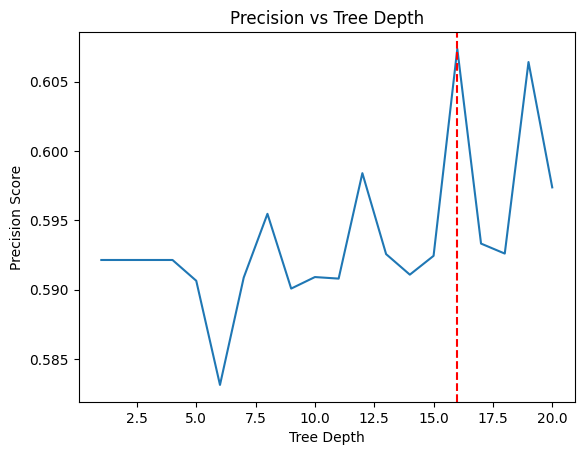

In [58]:
import matplotlib.pyplot as plt

plt.plot(range(1,21), precision_scores)
plt.xlabel('Tree Depth')
plt.ylabel('Precision Score')
plt.title('Precision vs Tree Depth')
plt.axvline(x=best_depth, color='r', linestyle='--')
plt.show()

### [EXPLORATORY] Question 5: What data is missing? 

Now that you have gained insights from the correlation analysis and Decision Tree results regarding the most influential variables, suggest new indicators you would like to include in the dataset and explain your reasoning.

Alternatively, you may propose a completely different approach based on your intuition, provided it remains relevant to the shared dataset of the largest stocks from India, the EU, and the US. If you choose this route, please also specify the data source.


To improve prediction accuracy, I would include earnings surprise data and analyst sentiment (e.g., EPS surprise, rating changes), as they often drive short-term stock movements. Additionally, adding global index returns (like S\&P 500 or NIFTY) and volatility measures (like VIX) can help capture broader market influence. Alternative data like Google Trends or news sentiment could further enhance signals, especially for retail-driven stocks.
